In [ ]:
import requests
import pandas as pd
from collections import Counter
import pickle
import sys
import numpy as np
from tqdm import tqdm
import time
import random
tqdm.pandas()
from pathlib import Path
import torch
from llama_index.embeddings.huggingface import HuggingFaceEmbedding
from transformers import AutoModelForCausalLM, AutoTokenizer
from llama_index.llms.huggingface import HuggingFaceLLM
from llama_index.core import VectorStoreIndex, SimpleDirectoryReader
from llama_index.core.response.notebook_utils import display_response
from llama_index.core.node_parser import SentenceSplitter
from llama_index.core.ingestion import IngestionPipeline, IngestionCache
from llama_index.core import StorageContext
from llama_index.core.query_engine import RetrieverQueryEngine
from llama_index.core.evaluation import SemanticSimilarityEvaluator
from huggingface_hub import login
from sklearn.metrics.pairwise import cosine_similarity
import warnings, logging
from sklearn.preprocessing import normalize
import matplotlib.pyplot as plt


/Users/mravi/miniconda3/envs/wf_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# embedding_model="BAAI/bge-small-en-v1.5"
embedding_model="BAAI/bge-base-en-v1.5"
embed_model = HuggingFaceEmbedding(model_name=embedding_model)


In [3]:
nodes = pd.read_pickle("nodes/pdf_and_news_with_hierarchies.pkl")
col="embedding_bge_base" if embedding_model=='BAAI/bge-base-en-v1.5' else "embedding_bge"
passage_embeddings=normalize(np.vstack(nodes[col].values))

In [4]:
questions=pd.read_csv("Wildfire_Benchmark_Questions.csv")
questions["question_with_location"] = questions.apply(
    lambda r: (
        r["Question"].rstrip("?") +
        " in " +
        ", ".join([str(r[c]) for c in ["Other","City","County","State","Region", "Country"] if pd.notna(r[c])]) +
        "?"
        if any(pd.notna(r[c]) for c in ["Other", "City","County","State","Region","Country"])
        else r["Question"]
    ),
    axis=1
)
questions=questions['question_with_location'].to_list()


In [5]:

def retrieval_pipeline(query, k, all_rank_scores, all_results):
    query_embedding=np.array(embed_model.get_query_embedding(query))
    scores=cosine_similarity(normalize(query_embedding.reshape(1,-1)), passage_embeddings)[0]
    top_index=np.argsort(scores)[::-1][:k]
    top_scores=scores[top_index]
    all_rank_scores.append(top_scores)
    results=nodes.iloc[top_index].copy()
    results["similarity_score"]=scores[top_index]
    results=results[['source', 'title', 'Text','similarity_score']]
    all_results.append(results)
    
    

In [6]:


kscores={}

for k in [3,5,10,15,20]:
    all_results=[]
    all_rank_scores=[]
    for i in questions:
        retrieval_pipeline(i, k,all_rank_scores, all_results)
    kscores[k]=all_rank_scores


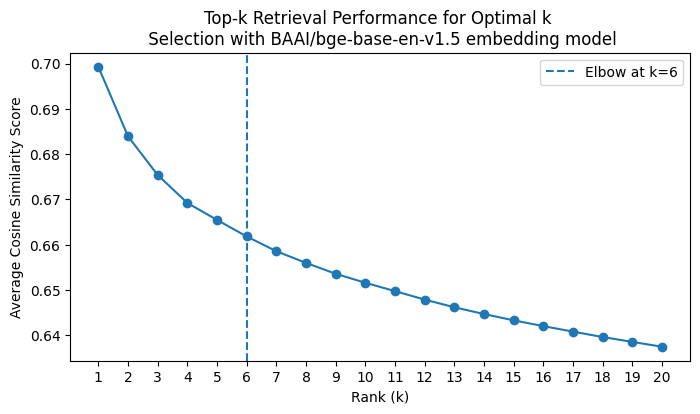

In [7]:

def find_knee(values, decreasing=True):
    y = np.asarray(values, dtype=float)
    x = np.arange(len(y))

    y = (y - y.min()) / (y.max() - y.min() + 1e-12)
    if decreasing:
        y = 1 - y  

    x1, y1 = x[0], y[0]
    x2, y2 = x[-1], y[-1]
    num = np.abs((y2 - y1) * x - (x2 - x1) * y + x2 * y1 - y2 * x1)
    den = np.hypot(y2 - y1, x2 - x1)
    knee_idx = int(np.argmax(num / (den + 1e-12)))
    return knee_idx
def plot_optimal_k(kscores, val):
    scores = np.vstack(kscores[val])
    avg_scores = scores.mean(axis=0)
    elbow_k = find_knee(avg_scores, decreasing=True)

    plt.figure(figsize=(8, 4))
    plt.plot(range(1, val+1), avg_scores, marker="o")
    plt.axvline(elbow_k, linestyle="--", label=f"Elbow at k={elbow_k}")

    plt.xlabel("Rank (k)")
    plt.ylabel("Average Cosine Similarity Score")
    plt.title(f"Top-k Retrieval Performance for Optimal k \n Selection with {embedding_model} embedding model")
    plt.xticks(range(1, val+1))
    plt.legend()
    plt.savefig(f"Images/{embedding_model.split('/')[-1]}_topk.png")
    plt.show()

    return elbow_k, avg_scores
elbow_k, avg_scores = plot_optimal_k(kscores,20)

In [ ]:
#Top ~5–6 retrieved passages contain most of the useful signal;
#  increasing k beyond this creates diminishing returns.
#The curve is smooth and flat after ~6.
#Small changes in k won’t break performance